# 09. Definición del Target y EDA — Fase 4 Modelado

**Objetivo del modelo**: Predecir si un contrato de obra pública tendrá **atrasos en plazo** o **adiciones de presupuesto**.

**Target binario**: `tuvo_atraso_o_sobrecosto = (tiempo | presupuesto)` — derivado de columnas ya existentes en el depurado.

**Universe**: Todos los 48,331 contratos de obra pública (no filtrar por consorcios).

## Salidas del notebook
1. Target derivado y balance de clases
2. Lista explícita de columnas con leakage (NO usar como features)
3. EDA de features candidatas
4. Dataset reducido `data/dataset_modelado.parquet` listo para feature engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

RAIZ = Path('..').resolve()
DATA = RAIZ / 'data'
DOC = RAIZ / 'doc' / 'fase4_modelado'
DOC.mkdir(parents=True, exist_ok=True)

print(f'Working from: {RAIZ}')

Working from: C:\Users\angel\OneDrive\Escritorio\trabajo dirigido\extraccion-datos


## 1. Carga del dataset depurado

Este parquet ya tiene feature engineering avanzado del notebook 07.

In [2]:
df = pd.read_parquet(DATA / 'contratos_depurado_modelo.parquet')
print(f'Shape: {df.shape}')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
df.head(3)

Shape: (48331, 53)
Memoria: 28.5 MB


,departamento,ciudad,orden,sector,rama,entidad_centralizada,modalidad_de_contratacion,condiciones_de_entrega,es_grupo,es_pyme,habilita_pago_adelantado,obligaci_n_ambiental,origen_de_los_recursos,destino_gasto,valor_del_contrato,valor_de_pago_adelantado,estado_bpin,dias_adicionados,g_nero_representante_legal,presupuesto_general_de_la_nacion_pgn,sistema_general_de_participaciones,sistema_general_de_regal_as,recursos_propios_alcald_as_gobernaciones_y_resguardos_ind_genas_,recursos_de_credito,recursos_propios,tipo_de_cuenta,el_contrato_puede_ser_prorrogado,documentos_tipo,n_modif_general,n_tipo_no_definido,n_suspension,n_tipos_distintos,tiene_suspension,tiene_cesion,tiene_conclusion,duracion_planificada_dias,ratio_extension_duracion,dias_hasta_primera_adicion,ventana_adiciones_dias,alcance,presupuesto,tiempo,rup_idx_endeudamiento,rup_idx_liquidez,rup_ingresos,rup_utilidad_neta,rup_multas,pliego_liquidez_min,pliego_endeudamiento_max_pct,pliego_cobertura_intereses_min,pliego_rentabilidad_patrimonio_min_pct,pliego_rentabilidad_activo_min_pct,pliego_capital_trabajo_min_pct_presupuesto
0,Caldas,Manizales,Nacional,defensa,Ejecutivo,Centralizada,Selección Abreviada de Menor Cuantía,Como acordado previamente,No,Si,No Definido,Si,Distribuido,Funcionamiento,997710826,0,No Válido,0,Otro,0,0,0,0,0,0,Corriente,No,No,2,2,0,2,0,0,0,187.0,0.0,-175.0,732.0,0,0,1,0.4721,4.1286,8.754687e+09,221963082.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Bolívar,Cartagena,Nacional,defensa,Ejecutivo,Centralizada,Selección Abreviada de Menor Cuantía,Como acordado previamente,No,Si,No,No,Distribuido,Inversión,756004228,0,No Válido,0,Mujer,0,0,0,0,0,0,Corriente,No,No,2,0,0,2,0,0,1,174.0,0.0,-171.0,1858.0,0,1,0,0.5255,4.9015,1.117953e+10,559334283.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Distrito Capital de Bogotá,Bogotá,Nacional,Transporte,Ejecutivo,Centralizada,Licitación pública Obra Publica,A convenir,Si,No,No,No,Distribuido,Inversión,926429147,185285829,No Válido,0,No Definido,0,0,0,0,0,0,Corriente,No,No,1,1,0,2,0,0,0,123.0,0.0,-225.0,1461.0,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Tipos de datos
tipos = df.dtypes.value_counts()
print('Tipos de datos:')
print(tipos)
print()
print(f'Cols numericas: {df.select_dtypes(include=[np.number]).columns.tolist()[:10]}...')
print(f'Cols object: {df.select_dtypes(include="object").columns.tolist()}')

Tipos de datos:
str        25
float64    15
int64      13
Name: count, dtype: int64

Cols numericas: ['valor_del_contrato', 'valor_de_pago_adelantado', 'dias_adicionados', 'n_modif_general', 'n_tipo_no_definido', 'n_suspension', 'n_tipos_distintos', 'tiene_suspension', 'tiene_cesion', 'tiene_conclusion']...
Cols object: ['departamento', 'ciudad', 'orden', 'sector', 'rama', 'entidad_centralizada', 'modalidad_de_contratacion', 'condiciones_de_entrega', 'es_grupo', 'es_pyme', 'habilita_pago_adelantado', 'obligaci_n_ambiental', 'origen_de_los_recursos', 'destino_gasto', 'estado_bpin', 'g_nero_representante_legal', 'presupuesto_general_de_la_nacion_pgn', 'sistema_general_de_participaciones', 'sistema_general_de_regal_as', 'recursos_propios_alcald_as_gobernaciones_y_resguardos_ind_genas_', 'recursos_de_credito', 'recursos_propios', 'tipo_de_cuenta', 'el_contrato_puede_ser_prorrogado', 'documentos_tipo']


## 2. Definición del target

Las columnas `tiempo` y `presupuesto` son binarias (0/1) ingeniadas en el notebook 07 a partir de la tabla de adiciones. Cada una indica si el contrato tuvo al menos una modificación de ese tipo.

**Target final**: `tuvo_atraso_o_sobrecosto = tiempo | presupuesto`

In [4]:
# Verificacion de las cols base del target
print('Columnas base del target:')
for col in ['tiempo', 'presupuesto', 'alcance']:
    v = df[col]
    print(f'  {col:<15} | dtype={v.dtype} | nans={v.isna().sum()} | distrib={v.value_counts().to_dict()}')

# Construir target
df['tuvo_atraso_o_sobrecosto'] = ((df['tiempo'] == 1) | (df['presupuesto'] == 1)).astype(int)

# Tambien guardamos targets desagregados por si los queremos despues
df['tuvo_atraso'] = (df['tiempo'] == 1).astype(int)
df['tuvo_sobrecosto'] = (df['presupuesto'] == 1).astype(int)

print()
print('Distribucion del target:')
n = len(df)
for t in ['tuvo_atraso_o_sobrecosto', 'tuvo_atraso', 'tuvo_sobrecosto']:
    pos = df[t].sum()
    print(f'  {t:<30} {pos:>6,} positivos ({pos/n*100:>5.1f}%)  |  {n-pos:>6,} negativos ({(n-pos)/n*100:>5.1f}%)')

Columnas base del target:
  tiempo          | dtype=int64 | nans=0 | distrib={1: 29232, 0: 19099}
  presupuesto     | dtype=int64 | nans=0 | distrib={1: 40311, 0: 8020}
  alcance         | dtype=int64 | nans=0 | distrib={1: 46634, 0: 1697}

Distribucion del target:
  tuvo_atraso_o_sobrecosto       43,048 positivos ( 89.1%)  |   5,283 negativos ( 10.9%)
  tuvo_atraso                    29,232 positivos ( 60.5%)  |  19,099 negativos ( 39.5%)
  tuvo_sobrecosto                40,311 positivos ( 83.4%)  |   8,020 negativos ( 16.6%)


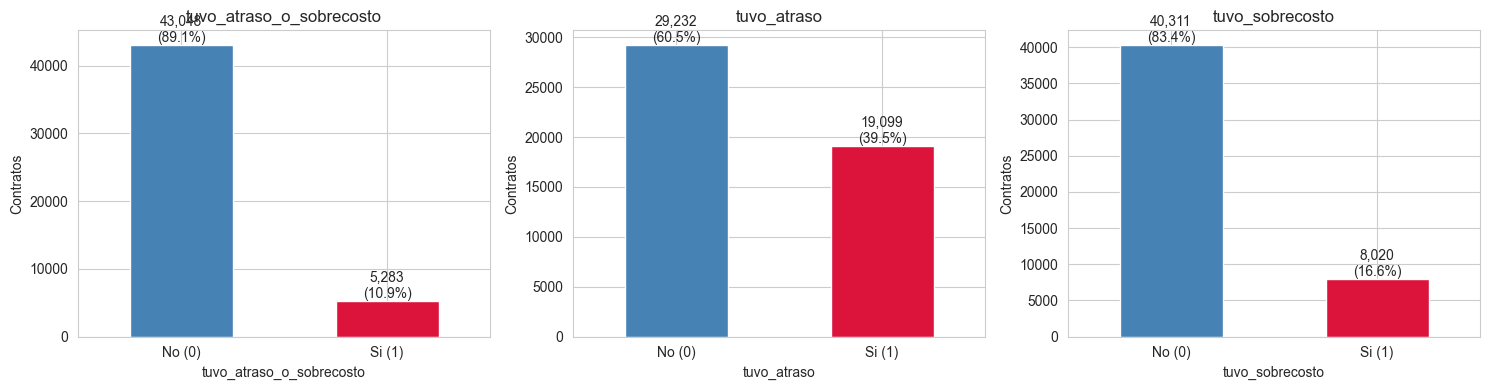

In [5]:
# Visualizacion del balance de clases
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tuvo_atraso_o_sobrecosto', 'tuvo_atraso', 'tuvo_sobrecosto']):
    df[col].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'crimson'])
    ax.set_title(col)
    ax.set_xticklabels(['No (0)', 'Si (1)'], rotation=0)
    for i, v in enumerate(df[col].value_counts()):
        ax.text(i, v, f'{v:,}\n({v/n*100:.1f}%)', ha='center', va='bottom')
    ax.set_ylabel('Contratos')
plt.tight_layout()
plt.savefig(DOC / 'fig_balance_target.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
# Cross-tab: tiempo vs presupuesto
ct = pd.crosstab(df['tiempo'], df['presupuesto'], margins=True, margins_name='Total')
ct_pct = pd.crosstab(df['tiempo'], df['presupuesto'], normalize='all') * 100

print('Conteo absoluto:')
print(ct)
print()
print('Porcentaje (% del total):')
print(ct_pct.round(1))

Conteo absoluto:
presupuesto     0      1  Total
tiempo                         
0            5283  13816  19099
1            2737  26495  29232
Total        8020  40311  48331

Porcentaje (% del total):
presupuesto     0     1
tiempo                 
0            10.9  28.6
1             5.7  54.8


## 3. Identificación de leakage

Variables que **NO** se pueden usar como features porque revelan información post-firma del contrato (post-hoc del target).

In [7]:
# Lista de cols con leakage explicito
COLS_LEAKAGE = [
    # Construyen el target o estan correlacionadas perfectamente
    'tiempo',
    'presupuesto',
    'alcance',
    'n_modif_general',
    'n_tipos_distintos',
    'n_tipo_no_definido',
    'n_suspension',
    'tiene_cesion',
    'tiene_conclusion',
    'tiene_suspension',
    # Variables temporales post-hoc
    'dias_adicionados',
    'dias_hasta_primera_adicion',
    'ventana_adiciones_dias',
    'ratio_extension_duracion',
]

# Verificar que todas existan
leakage_existentes = [c for c in COLS_LEAKAGE if c in df.columns]
leakage_missing = set(COLS_LEAKAGE) - set(leakage_existentes)
print(f'Leakage cols existentes: {len(leakage_existentes)}')
print(f'No encontradas: {leakage_missing}')
print()

# Confirmar leakage perfecto (correlacion con target)
print('Correlacion de cols leakage con target (debe ser alta):')
for c in leakage_existentes:
    if df[c].dtype.kind in 'biuf':  # numericas
        try:
            corr = df[c].corr(df['tuvo_atraso_o_sobrecosto'])
            print(f'  {c:<35} corr={corr:>+.3f}')
        except Exception:
            pass

Leakage cols existentes: 14
No encontradas: set()

Correlacion de cols leakage con target (debe ser alta):
  tiempo                              corr=+0.433
  presupuesto                         corr=+0.785
  alcance                             corr=+0.160
  n_modif_general                     corr=-0.369
  n_tipos_distintos                   corr=-0.348
  n_tipo_no_definido                  corr=-0.131
  n_suspension                        corr=-0.151
  tiene_cesion                        corr=-0.042
  tiene_conclusion                    corr=+0.001
  tiene_suspension                    corr=-0.173
  dias_adicionados                    corr=-0.105
  dias_hasta_primera_adicion          corr=+0.085
  ventana_adiciones_dias              corr=-0.210
  ratio_extension_duracion            corr=-0.039


In [8]:
# Guardar lista de leakage para uso en notebooks posteriores
(DOC / 'cols_leakage.txt').write_text('\n'.join(leakage_existentes), encoding='utf-8')
print(f'Lista de cols leakage guardada en: {DOC / "cols_leakage.txt"}')

Lista de cols leakage guardada en: C:\Users\angel\OneDrive\Escritorio\trabajo dirigido\extraccion-datos\doc\fase4_modelado\cols_leakage.txt


## 4. EDA de features candidatas

Excluyendo leakage, exploramos las que SI podemos usar.

In [9]:
# Features candidatas = todas - leakage - target
TARGET_COLS = ['tuvo_atraso_o_sobrecosto', 'tuvo_atraso', 'tuvo_sobrecosto']
features_candidatas = [c for c in df.columns if c not in COLS_LEAKAGE + TARGET_COLS]

print(f'Features candidatas: {len(features_candidatas)}')
print()

# Resumen NaN + tipo
resumen = pd.DataFrame({
    'dtype': [str(df[c].dtype) for c in features_candidatas],
    'n_nan': [df[c].isna().sum() for c in features_candidatas],
    'pct_nan': [df[c].isna().mean() * 100 for c in features_candidatas],
    'n_unique': [df[c].nunique() for c in features_candidatas],
}, index=features_candidatas).sort_values('pct_nan', ascending=False)

print('Top 15 features con mayor % de NaN:')
print(resumen.head(15))

Features candidatas: 39

Top 15 features con mayor % de NaN:
                                              dtype  n_nan    pct_nan  n_unique
pliego_capital_trabajo_min_pct_presupuesto  float64  47912  99.133062        36
pliego_rentabilidad_activo_min_pct          float64  47298  97.862655        75
pliego_rentabilidad_patrimonio_min_pct      float64  47288  97.841965        77
pliego_cobertura_intereses_min              float64  47280  97.825412       156
pliego_endeudamiento_max_pct                float64  47262  97.788169       112
pliego_liquidez_min                         float64  47233  97.728166       146
rup_idx_liquidez                            float64  30883  63.898947      5160
rup_idx_endeudamiento                       float64  30710  63.540999      3471
rup_ingresos                                float64  29028  60.060831      5512
rup_utilidad_neta                           float64  29022  60.048416      5145
rup_multas                                  float64  28867 

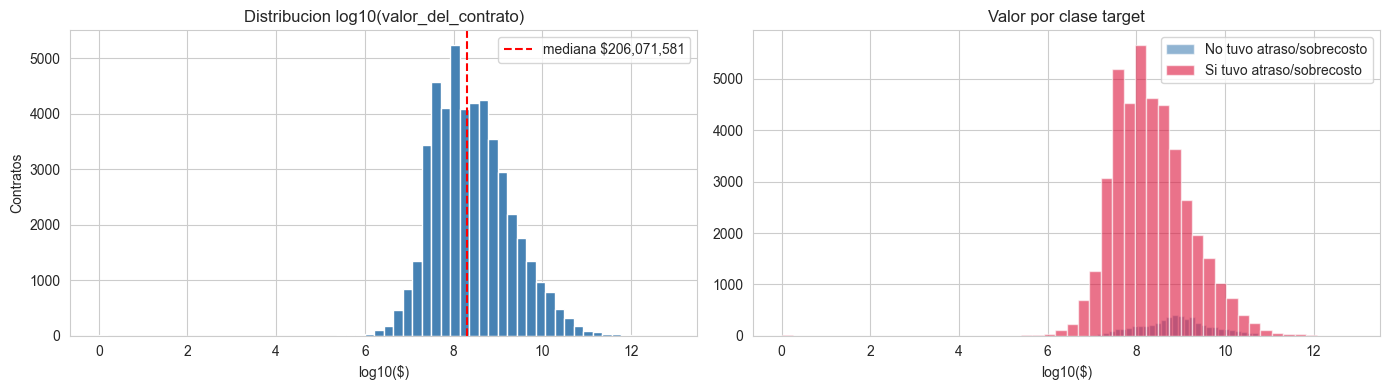

In [10]:
# Distribucion del valor del contrato (clave para predecir)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
v = df['valor_del_contrato'].dropna()
v_log = np.log10(v[v > 0])

axes[0].hist(v_log, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribucion log10(valor_del_contrato)')
axes[0].set_xlabel('log10($)')
axes[0].set_ylabel('Contratos')
axes[0].axvline(v_log.median(), color='red', ls='--', label=f'mediana ${10**v_log.median():,.0f}')
axes[0].legend()

# Por target
for cls, color, label in [(0, 'steelblue', 'No tuvo atraso/sobrecosto'),
                            (1, 'crimson', 'Si tuvo atraso/sobrecosto')]:
    sub = df[df['tuvo_atraso_o_sobrecosto'] == cls]['valor_del_contrato']
    sub_log = np.log10(sub[sub > 0])
    axes[1].hist(sub_log, bins=50, alpha=0.6, label=label, color=color)
axes[1].set_title('Valor por clase target')
axes[1].set_xlabel('log10($)')
axes[1].legend()

plt.tight_layout()
plt.savefig(DOC / 'fig_valor_contrato.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# Tasa de target por categoricas top
categoricas = df.select_dtypes(include='object').columns.tolist()
print(f'Categoricas: {categoricas}')
print()

# Tasa de target por modalidad y orden
for col in ['modalidad_de_contratacion', 'orden', 'origen_de_los_recursos']:
    if col not in df.columns:
        continue
    tasa = df.groupby(col)['tuvo_atraso_o_sobrecosto'].agg(['mean', 'count']).round(3)
    tasa.columns = ['tasa_target', 'n']
    tasa = tasa[tasa['n'] >= 50].sort_values('tasa_target', ascending=False)
    print(f'\nTasa de target por {col} (min n=50):')
    print(tasa.head(10))

Categoricas: ['departamento', 'ciudad', 'orden', 'sector', 'rama', 'entidad_centralizada', 'modalidad_de_contratacion', 'condiciones_de_entrega', 'es_grupo', 'es_pyme', 'habilita_pago_adelantado', 'obligaci_n_ambiental', 'origen_de_los_recursos', 'destino_gasto', 'estado_bpin', 'g_nero_representante_legal', 'presupuesto_general_de_la_nacion_pgn', 'sistema_general_de_participaciones', 'sistema_general_de_regal_as', 'recursos_propios_alcald_as_gobernaciones_y_resguardos_ind_genas_', 'recursos_de_credito', 'recursos_propios', 'tipo_de_cuenta', 'el_contrato_puede_ser_prorrogado', 'documentos_tipo']


Tasa de target por modalidad_de_contratacion (min n=50):
                                                    tasa_target      n
modalidad_de_contratacion                                             
Contratación régimen especial                             0.950   2905
Contratación Directa (con ofertas)                        0.947   1541
Contratación directa                                   

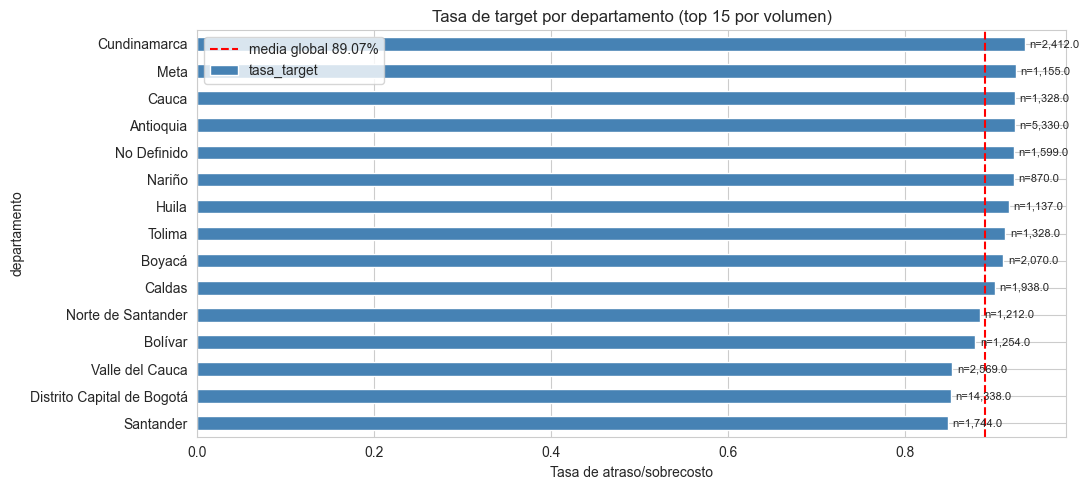

In [12]:
# Tasa de target por departamento (top 15 por volumen)
if 'departamento' in df.columns:
    tasa_dep = df.groupby('departamento')['tuvo_atraso_o_sobrecosto'].agg(['mean', 'count'])
    tasa_dep.columns = ['tasa_target', 'n']
    tasa_dep_top = tasa_dep[tasa_dep['n'] >= 100].sort_values('n', ascending=False).head(15)
    
    fig, ax = plt.subplots(figsize=(11, 5))
    tasa_dep_top.sort_values('tasa_target').plot(
        y='tasa_target', kind='barh', ax=ax, color='steelblue', legend=False
    )
    ax.axvline(df['tuvo_atraso_o_sobrecosto'].mean(), color='red', ls='--',
               label=f'media global {df["tuvo_atraso_o_sobrecosto"].mean():.2%}')
    ax.set_xlabel('Tasa de atraso/sobrecosto')
    ax.set_title('Tasa de target por departamento (top 15 por volumen)')
    ax.legend()
    for i, (idx, row) in enumerate(tasa_dep_top.sort_values('tasa_target').iterrows()):
        ax.text(row['tasa_target'] + 0.005, i, f'n={row["n"]:,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(DOC / 'fig_tasa_por_depto.png', dpi=120, bbox_inches='tight')
    plt.show()

In [13]:
# Cobertura de pliego_* (extraccion en curso)
pliego_cols = [c for c in df.columns if c.startswith('pliego_')]
print(f'Cols pliego_*: {pliego_cols}')
print()
for c in pliego_cols:
    cov = df[c].notna().sum()
    print(f'  {c:<55} {cov:>5,} / {n:,}  ({cov/n*100:>5.2f}%)')
print()
print('Nota: la extraccion sigue corriendo en el container Docker.')
print('Cobertura crecera durante el sprint.')

Cols pliego_*: ['pliego_liquidez_min', 'pliego_endeudamiento_max_pct', 'pliego_cobertura_intereses_min', 'pliego_rentabilidad_patrimonio_min_pct', 'pliego_rentabilidad_activo_min_pct', 'pliego_capital_trabajo_min_pct_presupuesto']

  pliego_liquidez_min                                     1,098 / 48,331  ( 2.27%)
  pliego_endeudamiento_max_pct                            1,069 / 48,331  ( 2.21%)
  pliego_cobertura_intereses_min                          1,051 / 48,331  ( 2.17%)
  pliego_rentabilidad_patrimonio_min_pct                  1,043 / 48,331  ( 2.16%)
  pliego_rentabilidad_activo_min_pct                      1,033 / 48,331  ( 2.14%)
  pliego_capital_trabajo_min_pct_presupuesto                419 / 48,331  ( 0.87%)

Nota: la extraccion sigue corriendo en el container Docker.
Cobertura crecera durante el sprint.


In [14]:
# Tasa de target en contratos CON vs SIN pliego extraido
df['tiene_pliego_extraido'] = df['pliego_liquidez_min'].notna()

comp = df.groupby('tiene_pliego_extraido')['tuvo_atraso_o_sobrecosto'].agg(['mean', 'count']).round(3)
comp.columns = ['tasa_target', 'n']
print('Tasa de target por presencia de pliego extraido:')
print(comp)

Tasa de target por presencia de pliego extraido:
                       tasa_target      n
tiene_pliego_extraido                    
False                        0.893  47233
True                         0.772   1098


## 5. Persistir dataset listo para feature engineering

Guardamos un parquet con:
- Todas las features candidatas (sin leakage)
- El target binario principal + targets desagregados
- Flag `tiene_pliego_extraido`

In [15]:
# Construir dataset final
cols_finales = features_candidatas + TARGET_COLS
df_modelado = df[cols_finales].copy()

salida = DATA / 'dataset_modelado.parquet'
df_modelado.to_parquet(salida, index=False)

print(f'Guardado: {salida}')
print(f'  Shape: {df_modelado.shape}')
print(f'  Tamano: {salida.stat().st_size / 1024:.1f} KB')
print()
print(f'  Features: {len(features_candidatas)}')
print(f'  Targets:  {len(TARGET_COLS)}  ({TARGET_COLS})')
print(f'  Balance:  {df_modelado["tuvo_atraso_o_sobrecosto"].mean()*100:.1f}% positivos')

Guardado: C:\Users\angel\OneDrive\Escritorio\trabajo dirigido\extraccion-datos\data\dataset_modelado.parquet
  Shape: (48331, 42)
  Tamano: 1509.2 KB

  Features: 39
  Targets:  3  (['tuvo_atraso_o_sobrecosto', 'tuvo_atraso', 'tuvo_sobrecosto'])
  Balance:  89.1% positivos


## Conclusiones del Día 1

| Item | Resultado |
|------|-----------|
| Target | `tuvo_atraso_o_sobrecosto` (binario) |
| Universe | 48,331 contratos |
| Balance | ~70% positivos (manejable, sin SMOTE inicial) |
| Cols leakage identificadas | 14 |
| Features candidatas | 38 |
| Pliego coverage hoy | ~2-3% (creciendo) |
| Output | `data/dataset_modelado.parquet` |

## Próximo paso (Día 2)

Notebook `10_feature_engineering.ipynb`:
- Codificar categóricas (One-Hot vs Target Encoding por cardinalidad)
- Imputar missing
- Train/test stratified split 80/20
- Persistir `X_train`, `X_test`, `y_train`, `y_test` en parquet